
STARTING SIMULATION FOR HEATING RATE: 20.0°C/min

[INIT] Run 61 started.
[INFO] Report generated with T_max = 800.0°C
[20.0 DPM] Time: 0.0 min | Bulk T: 40.6 C | Conv: 13.63%
[20.0 DPM] Time: 1.0 min | Bulk T: 43.1 C | Conv: 23.35%
[20.0 DPM] Time: 2.0 min | Bulk T: 46.8 C | Conv: 23.89%
[20.0 DPM] Time: 3.0 min | Bulk T: 51.4 C | Conv: 24.13%
[20.0 DPM] Time: 4.0 min | Bulk T: 56.9 C | Conv: 24.27%
[20.0 DPM] Time: 5.0 min | Bulk T: 62.9 C | Conv: 24.37%
[20.0 DPM] Time: 6.0 min | Bulk T: 69.5 C | Conv: 24.45%
[20.0 DPM] Time: 7.0 min | Bulk T: 76.7 C | Conv: 24.51%
[20.0 DPM] Time: 8.0 min | Bulk T: 84.3 C | Conv: 24.56%
[20.0 DPM] Time: 9.0 min | Bulk T: 92.4 C | Conv: 24.62%
[20.0 DPM] Time: 10.0 min | Bulk T: 100.8 C | Conv: 24.69%
[20.0 DPM] Time: 11.0 min | Bulk T: 109.6 C | Conv: 24.82%
[20.0 DPM] Time: 12.0 min | Bulk T: 118.8 C | Conv: 25.08%
[20.0 DPM] Time: 13.0 min | Bulk T: 128.3 C | Conv: 25.50%
[20.0 DPM] Time: 14.0 min | Bulk T: 138.1 C | Conv: 26.13%
[20.0 DPM] Time:

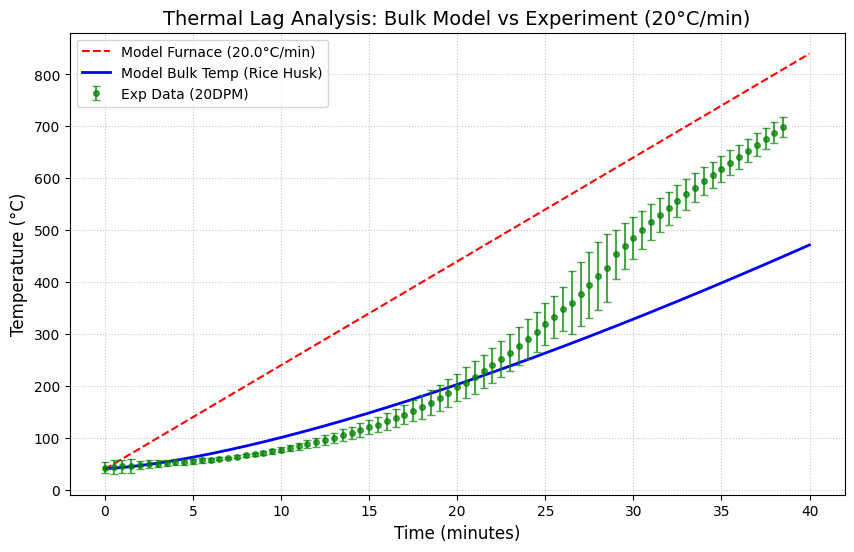

[DONE] Report and logs saved in c:\Users\manas\OneDrive\Documents\Library\CHEMICAL\Major Project\implementing gas moles\pyrolysis_project\results\run_61
[FINISH] Run for 20.0°C/min completed. Results in: c:\Users\manas\OneDrive\Documents\Library\CHEMICAL\Major Project\implementing gas moles\pyrolysis_project\results\run_61

STARTING SIMULATION FOR HEATING RATE: 40.0°C/min

[INIT] Run 62 started.
[INFO] Report generated with T_max = 800.0°C
[40.0 DPM] Time: 0.0 min | Bulk T: 40.6 C | Conv: 13.63%
[40.0 DPM] Time: 1.0 min | Bulk T: 45.3 C | Conv: 23.37%
[40.0 DPM] Time: 2.0 min | Bulk T: 52.7 C | Conv: 23.91%
[40.0 DPM] Time: 3.0 min | Bulk T: 62.0 C | Conv: 24.16%
[40.0 DPM] Time: 4.0 min | Bulk T: 72.9 C | Conv: 24.31%
[40.0 DPM] Time: 5.0 min | Bulk T: 85.0 C | Conv: 24.44%
[40.0 DPM] Time: 6.0 min | Bulk T: 98.3 C | Conv: 24.66%
[40.0 DPM] Time: 7.0 min | Bulk T: 112.7 C | Conv: 25.23%
[40.0 DPM] Time: 8.0 min | Bulk T: 127.9 C | Conv: 26.38%
[40.0 DPM] Time: 9.0 min | Bulk T: 144.0 

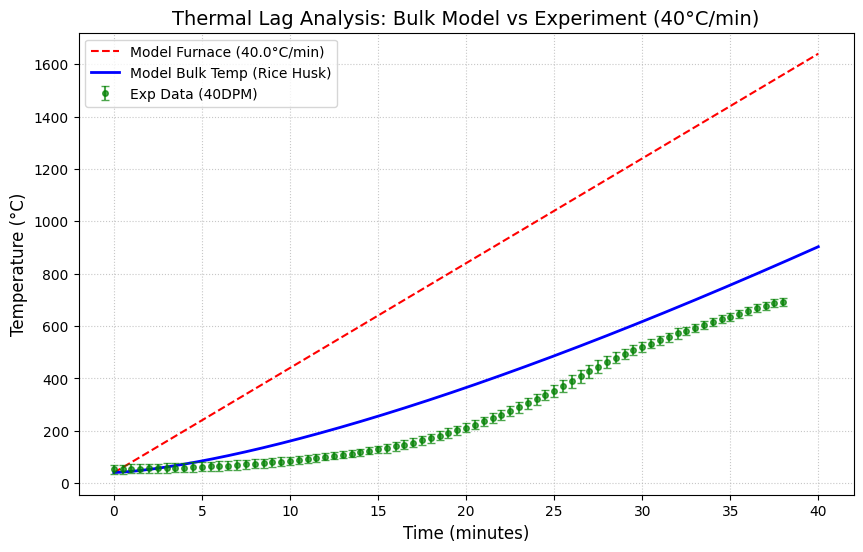

[DONE] Report and logs saved in c:\Users\manas\OneDrive\Documents\Library\CHEMICAL\Major Project\implementing gas moles\pyrolysis_project\results\run_62
[FINISH] Run for 40.0°C/min completed. Results in: c:\Users\manas\OneDrive\Documents\Library\CHEMICAL\Major Project\implementing gas moles\pyrolysis_project\results\run_62


In [6]:
from config import Config
from core.mesh import Mesh
from core.fvm_solver import PackedBedSolver
from core.kinetics import KineticsEngine
from utils.io_manager import IOManager
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd  

def main():
    # 1. Initialize Base Configuration and Grid
    base_cfg = Config()
    mesh = Mesh(base_cfg)
    
    # Define the two heating rates to simulate
    heating_rates_to_run = [20.0, 40.0]

    for rate in heating_rates_to_run:
        print(f"\n" + "="*50)
        print(f"STARTING SIMULATION FOR HEATING RATE: {rate}°C/min")
        print("="*50)
        
        # Update current heating rate
        base_cfg.HEATING_RATE = rate
        
        # 2. Initialize Engines for this specific rate
        solver = PackedBedSolver(base_cfg, mesh)
        kinetics = KineticsEngine(base_cfg)
        io = IOManager(base_cfg) # New run folder created here

        # --- TRACKING LISTS ---
        time_history = []
        bulk_avg_temp_history = [] 
        furnace_temp_history = []

        # 3. Initialize State Variables (Reset for every run)
        T = np.full((base_cfg.NR, base_cfg.NZ), base_cfg.T_INIT)
        P = np.full((base_cfg.NR, base_cfg.NZ), base_cfg.P_ATM)
        alpha = {f'alpha_{i}': np.full((base_cfg.NR, base_cfg.NZ), 1.0) for i in range(1, 5)}

        # 4. Simulation Parameters
        total_steps = int(base_cfg.TOTAL_MIN * 60 / base_cfg.DT)
        steps_per_min = int(60 / base_cfg.DT) 

        # 5. Main Simulation Loop
        for step in range(total_steps):
            curr_sec = step * base_cfg.DT
            curr_min = curr_sec / 60.0
            T_amb = base_cfg.T_INIT + (base_cfg.HEATING_RATE / 60.0) * curr_sec
            
            # Physics steps
            alpha, dn_gen, q_rxn = kinetics.compute_step(alpha, T, base_cfg.DT, mesh.V)
            P = solver.solve_pressure(P, T, dn_gen)
            T = solver.solve_heat(T, P, T_amb, q_rxn)

            # Volume-Weighted Bulk Average Temperature
            total_vol = np.sum(mesh.V)
            avg_bulk_t_k = np.sum(T * mesh.V) / total_vol
            avg_bulk_t_c = avg_bulk_t_k - 273.15
            
            time_history.append(curr_min)
            bulk_avg_temp_history.append(avg_bulk_t_c)
            furnace_temp_history.append(T_amb - 273.15)

            if step % steps_per_min == 0:
                global_conv = 1.0 - np.mean([np.mean(alpha[a]) for a in alpha])
                print(f"[{rate} DPM] Time: {curr_min:.1f} min | Bulk T: {avg_bulk_t_c:.1f} C | Conv: {global_conv:.2%}")
                io.save_iteration_data(T, P, alpha, q_rxn, curr_min)

        # --- 7. GENERATE THERMAL ANALYSIS REPORT FOR THIS RATE ---
        plt.figure(figsize=(10, 6))
        
        # A. Plot Simulation Lines
        plt.plot(time_history, furnace_temp_history, 'r--', label=f'Model Furnace ({rate}°C/min)')
        plt.plot(time_history, bulk_avg_temp_history, 'b-', linewidth=2, label='Model Bulk Temp (Rice Husk)')
        
        # B. Plot Experimental Data Mapping 
        try:
            folder_name = "Experimental data"
            file_name = "Experimental_Data.xlsx"
            exp_path = os.path.join(folder_name, file_name)
            sheet_name = f"{int(rate)}DPM"
            
            if os.path.exists(exp_path):
                df_exp = pd.read_excel(exp_path, sheet_name=sheet_name)
                df_exp.columns = [str(c).strip().lower() for c in df_exp.columns]
                
                if 'time (s)' in df_exp.columns and 'avg' in df_exp.columns:
                    plt.errorbar(df_exp['time (s)']/60.0, df_exp['avg'], 
                                 yerr=df_exp['std dev'] if 'std dev' in df_exp.columns else None, 
                                 fmt='go', label=f'Exp Data ({sheet_name})', 
                                 capsize=3, markersize=4, alpha=0.7)
                    print(f"[SUCCESS] Mapped experimental data for {sheet_name}")
            else:
                print(f"[WARNING] Experimental file not found at: {exp_path}")
        except Exception as e:
            print(f"[ERROR] Experimental mapping failed for {rate}DPM: {e}")

        # C. Formatting
        plt.title(f"Thermal Lag Analysis: Bulk Model vs Experiment ({int(rate)}°C/min)", fontsize=14)
        plt.xlabel("Time (minutes)", fontsize=12)
        plt.ylabel("Temperature (°C)", fontsize=12)
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.7)
        
        report_name = f"thermal_report_bulk_{int(rate)}DPM.png"
        report_path = os.path.join(io.run_dir, report_name)
        plt.savefig(report_path, dpi=150)
        plt.show()

        # 8. Finalize Run for this rate
        io.finalize()
        print(f"[FINISH] Run for {rate}°C/min completed. Results in: {io.run_dir}")

if __name__ == "__main__":
    main()

In [7]:
import sys
# This clears the memory of your custom modules
if 'core.kinetics' in sys.modules:
    del sys.modules['core.kinetics']
if 'core.fvm_solver' in sys.modules:
    del sys.modules['core.fvm_solver']
if 'config' in sys.modules:
    del sys.modules['config']

print("Memory cleared. Now restart the kernel and run main again.")

Memory cleared. Now restart the kernel and run main again.
